# 🧠 EDA — Stroke Prediction Dataset
Análise Exploratória de Dados completa para o dataset de predição de AVC (Stroke).

**Fonte:** Kaggle — Healthcare Dataset Stroke Data  
**Objetivo:** Entender a distribuição, qualidade e relações entre as variáveis para guiar o pré-processamento e modelagem.

---


## 1. Imports e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})
print("✅ Bibliotecas importadas com sucesso.")


✅ Bibliotecas importadas com sucesso.


## 2. Carregamento e Visão Geral dos Dados

In [2]:
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head(10)


Shape: 5110 linhas × 12 colunas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
print("=== TIPOS DE DADOS ===")
print(df.dtypes)
print()
print("=== VALORES NULOS ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print()
print("=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS ===")
df.describe().round(2)


=== TIPOS DE DADOS ===
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

=== VALORES NULOS ===
bmi    201
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS ===


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


In [4]:
# Verificar 'bmi' que veio com 'N/A' como string antes do parse
print("Valores únicos problemáticos em bmi:", df['bmi'].isna().sum(), "nulos")
print()
# Valores únicos por variável categórica
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(f"{col}: {df[col].value_counts().to_dict()}")
    print()


Valores únicos problemáticos em bmi: 201 nulos

gender: {'Female': 2994, 'Male': 2115, 'Other': 1}

ever_married: {'Yes': 3353, 'No': 1757}

work_type: {'Private': 2925, 'Self-employed': 819, 'children': 687, 'Govt_job': 657, 'Never_worked': 22}

Residence_type: {'Urban': 2596, 'Rural': 2514}

smoking_status: {'never smoked': 1892, 'Unknown': 1544, 'formerly smoked': 885, 'smokes': 789}



## 3. Análise da Variável Target — `stroke`
> **Problema de classe desbalanceada:** verificar a proporção de AVC vs. não-AVC.


Contagem absoluta:
stroke
0    4861
1     249
Name: count, dtype: int64

Proporção (%):
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


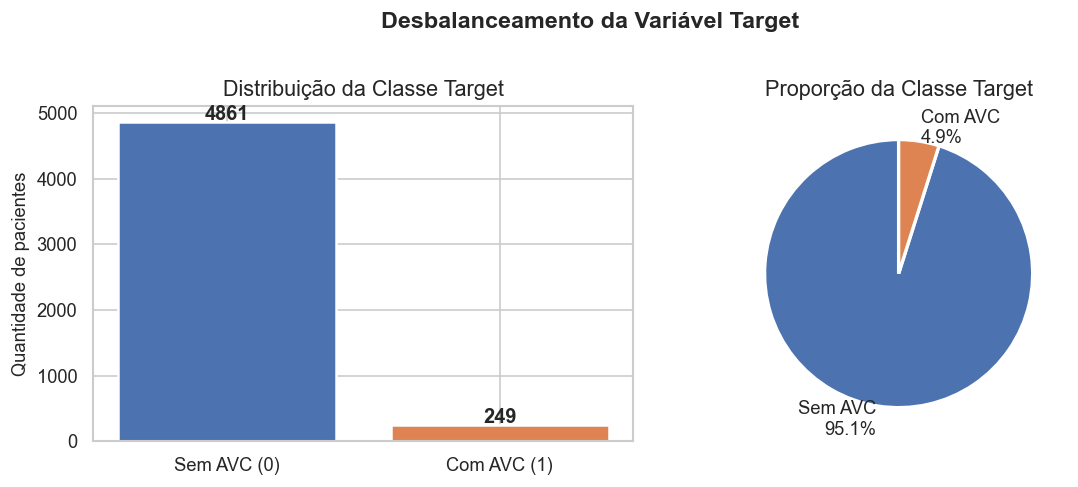


⚠️  ATENÇÃO: Dataset fortemente desbalanceado — apenas ~4.9% com AVC.
   Técnicas como SMOTE, class_weight ou threshold tuning serão necessárias.


In [5]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print("Contagem absoluta:")
print(stroke_counts)
print()
print("Proporção (%):")
print(stroke_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barplot
axes[0].bar(['Sem AVC (0)', 'Com AVC (1)'], stroke_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição da Classe Target')
axes[0].set_ylabel('Quantidade de pacientes')
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(stroke_counts.values,
            labels=[f'Sem AVC\n{stroke_pct[0]:.1f}%', f'Com AVC\n{stroke_pct[1]:.1f}%'],
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção da Classe Target')

plt.suptitle('Desbalanceamento da Variável Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_target.png', bbox_inches='tight')
plt.show()
print()
print("⚠️  ATENÇÃO: Dataset fortemente desbalanceado — apenas ~4.9% com AVC.")
print("   Técnicas como SMOTE, class_weight ou threshold tuning serão necessárias.")


## 4. Distribuição das Variáveis Numéricas

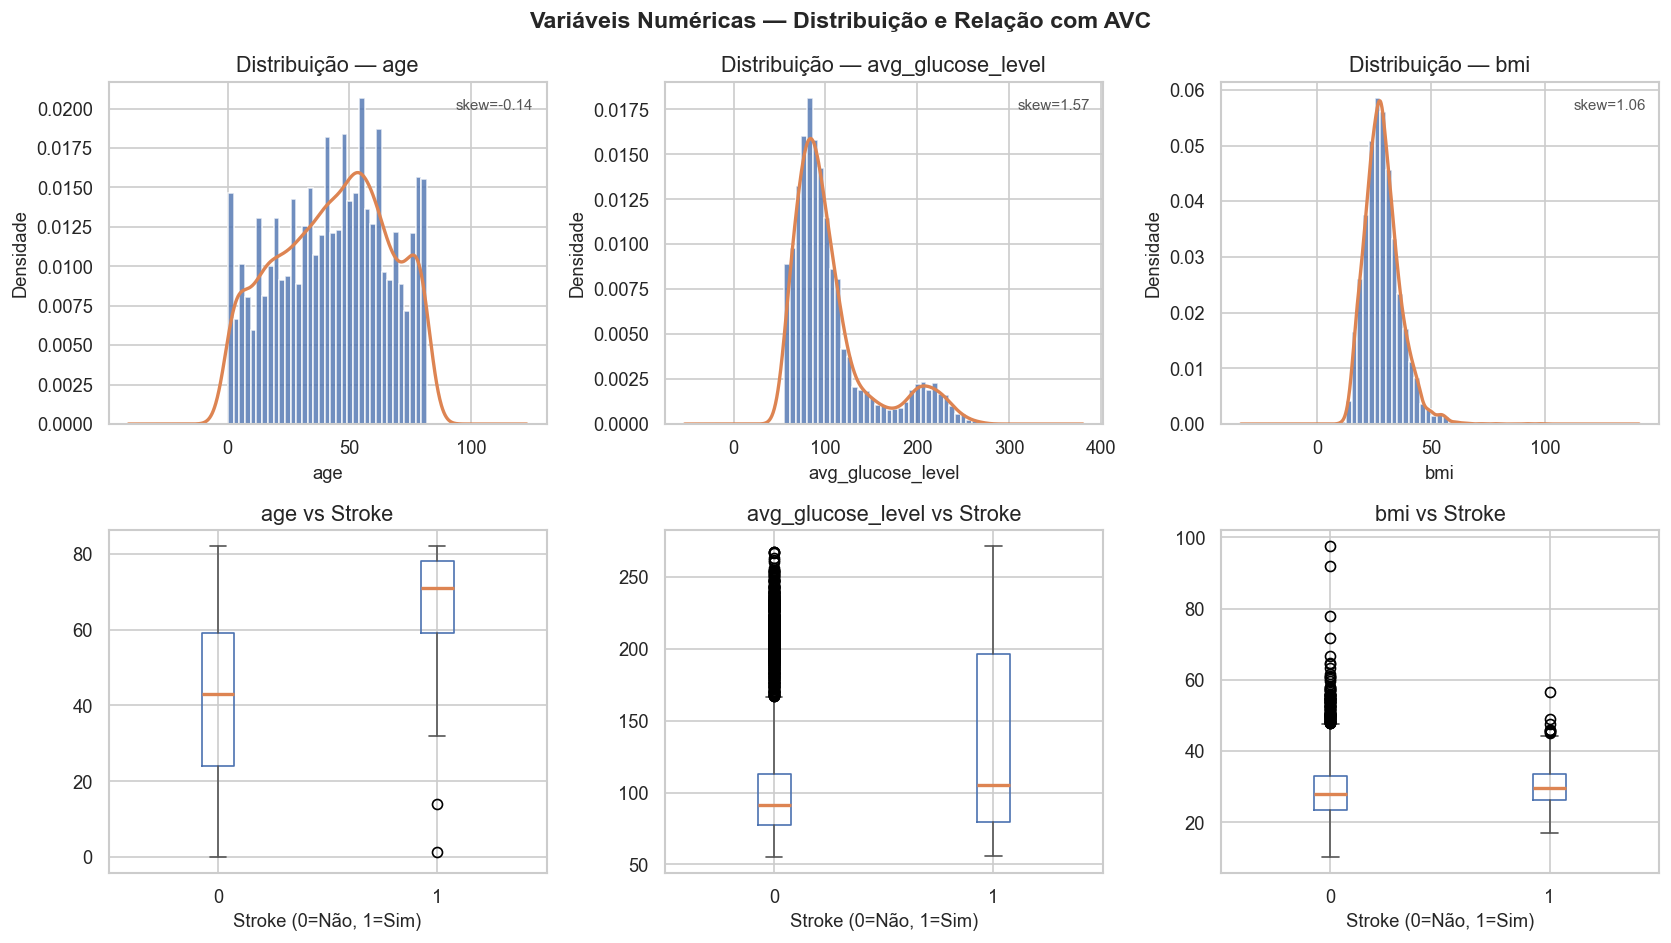

In [6]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histograma + KDE
    axes[0, i].hist(data, bins=35, color='#4C72B0', edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=axes[0, i], color='#DD8452', linewidth=2)
    axes[0, i].set_title(f'Distribuição — {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Densidade')
    skew = data.skew()
    axes[0, i].text(0.97, 0.95, f'skew={skew:.2f}', transform=axes[0, i].transAxes,
                    ha='right', va='top', fontsize=9, color='#555')

    # Boxplot por stroke
    df.boxplot(column=col, by='stroke', ax=axes[1, i],
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='#DD8452', linewidth=2),
               whiskerprops=dict(color='#555'),
               capprops=dict(color='#555'))
    axes[1, i].set_title(f'{col} por Stroke')
    axes[1, i].set_xlabel('Stroke (0=Não, 1=Sim)')
    plt.sca(axes[1, i])
    plt.title(f'{col} vs Stroke')

plt.suptitle('Variáveis Numéricas — Distribuição e Relação com AVC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_numericas.png', bbox_inches='tight')
plt.show()


In [7]:
# Teste estatístico: Mann-Whitney U (não paramétrico — distribuições assimétricas)
print("=== TESTE MANN-WHITNEY U: comparação entre grupos stroke=0 e stroke=1 ===")
for col in num_cols:
    g0 = df[df['stroke'] == 0][col].dropna()
    g1 = df[df['stroke'] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '✅ Significativo' if p < 0.05 else '❌ Não significativo'
    print(f"  {col}: p={p:.4e}  →  {sig}")


=== TESTE MANN-WHITNEY U: comparação entre grupos stroke=0 e stroke=1 ===
  age: p=3.7266e-71  →  ✅ Significativo
  avg_glucose_level: p=3.6404e-09  →  ✅ Significativo
  bmi: p=1.0264e-04  →  ✅ Significativo


## 5. Distribuição das Variáveis Categóricas

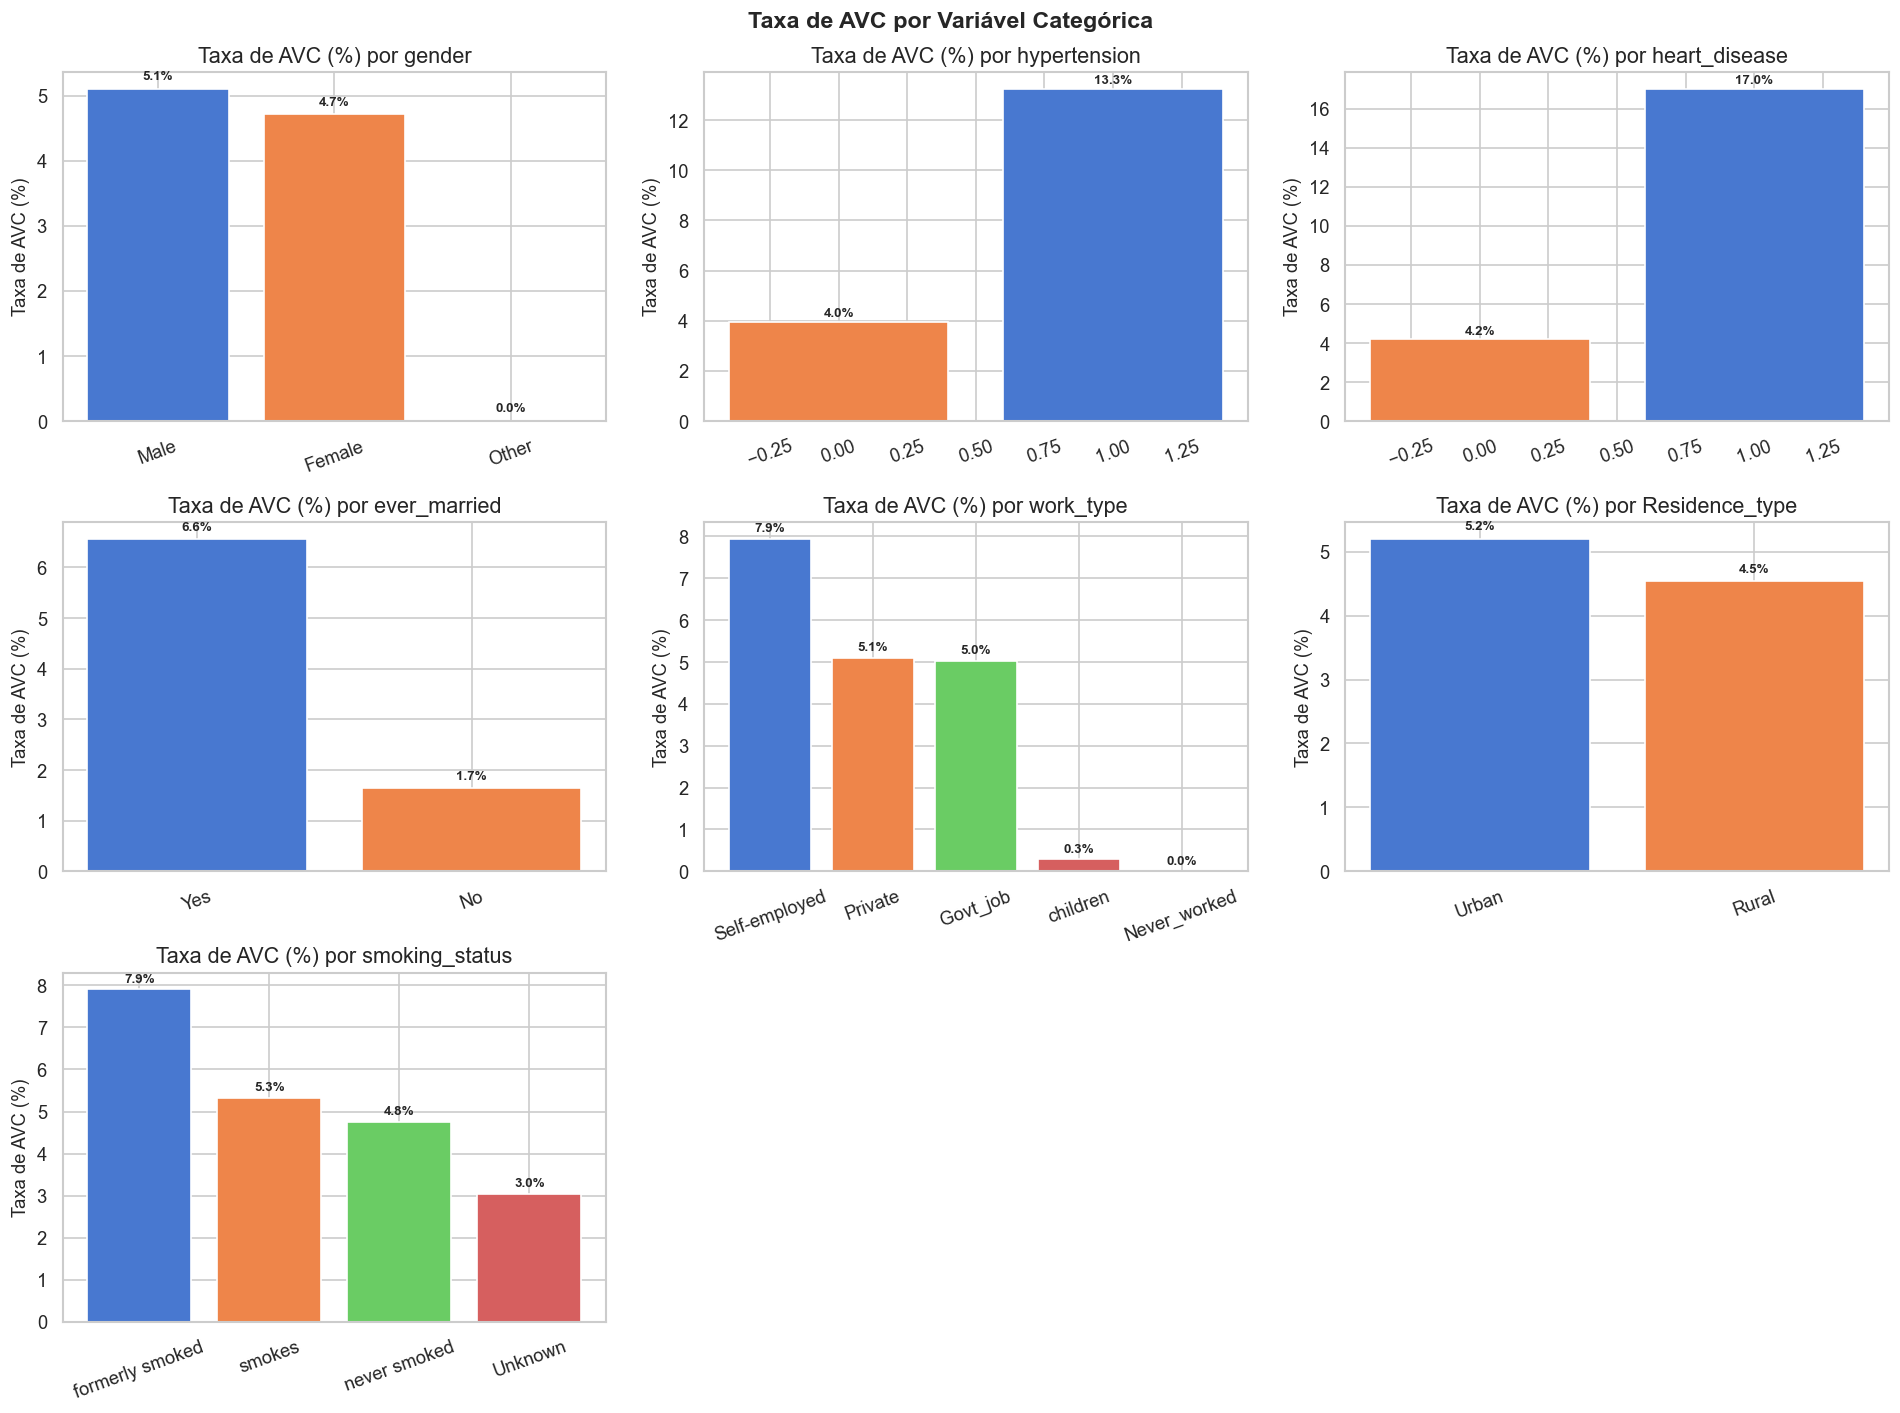

In [8]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
           'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    colors = sns.color_palette('muted', len(stroke_rate))
    bars = axes[i].bar(stroke_rate.index, stroke_rate.values, color=colors, edgecolor='white')
    axes[i].set_title(f'Taxa de AVC (%) por {col}')
    axes[i].set_ylabel('Taxa de AVC (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, stroke_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Remover subplot extra
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Taxa de AVC por Variável Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_categoricas.png', bbox_inches='tight')
plt.show()


## 6. Matriz de Correlação

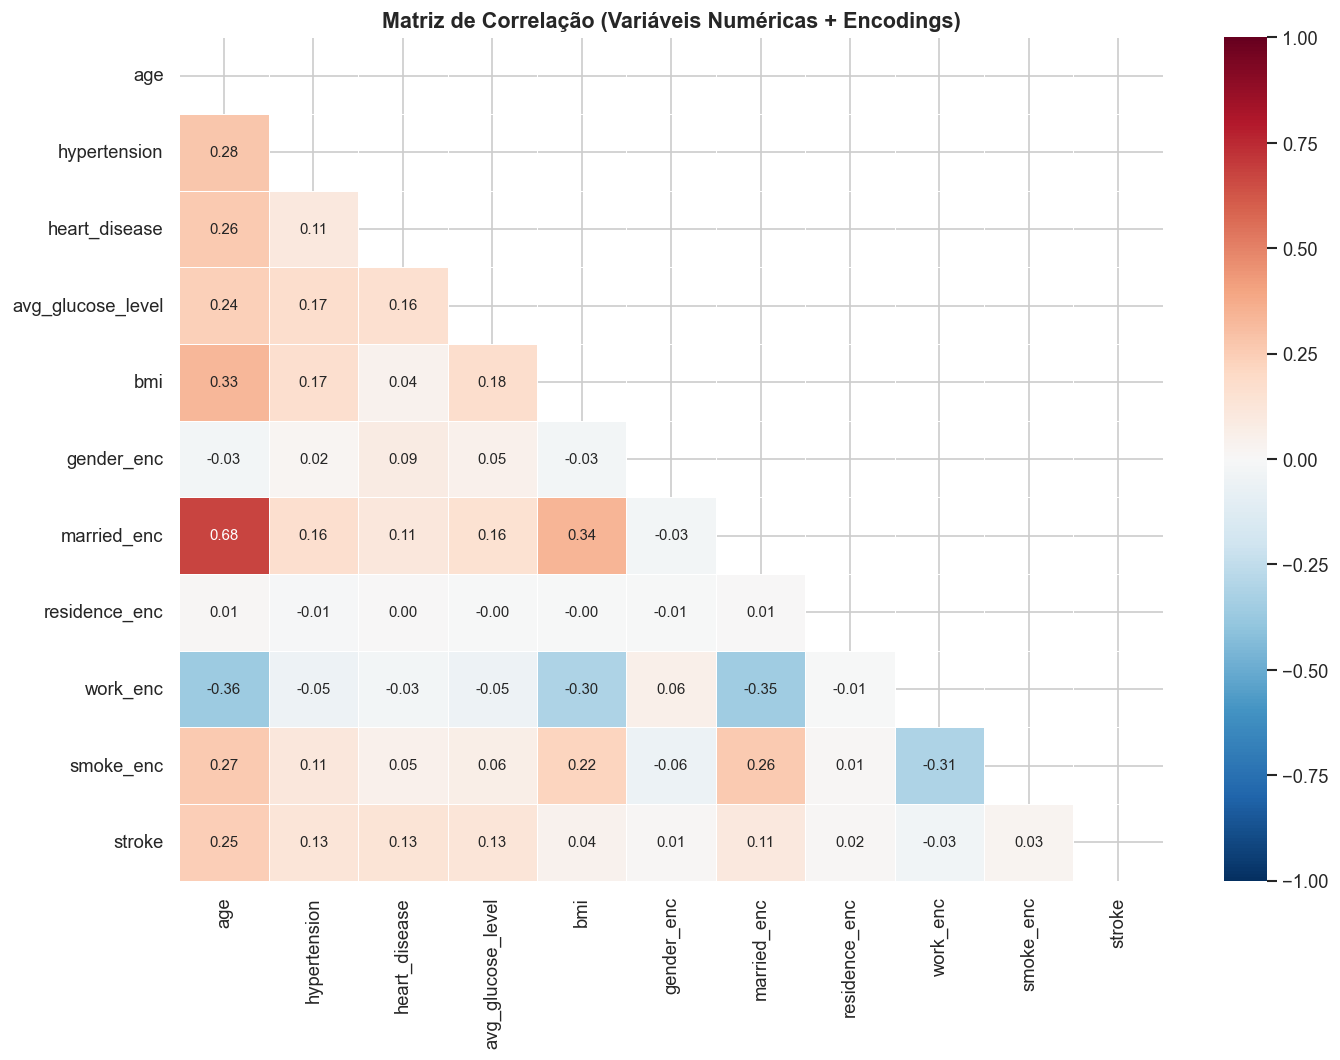

=== Top correlações com 'stroke' ===
age                  0.245
heart_disease        0.135
avg_glucose_level    0.132
hypertension         0.128
married_enc          0.108
bmi                  0.042
work_enc            -0.032
smoke_enc            0.028
residence_enc        0.015
gender_enc           0.009
Name: stroke, dtype: float64


In [9]:
# Encoding rápido para correlação
df_enc = df.copy()
df_enc['gender_enc'] = (df['gender'] == 'Male').astype(int)
df_enc['married_enc'] = (df['ever_married'] == 'Yes').astype(int)
df_enc['residence_enc'] = (df['Residence_type'] == 'Urban').astype(int)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_enc['work_enc'] = le.fit_transform(df['work_type'])
df_enc['smoke_enc'] = le.fit_transform(df['smoking_status'])

corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
             'gender_enc', 'married_enc', 'residence_enc', 'work_enc', 'smoke_enc', 'stroke']

corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação (Variáveis Numéricas + Encodings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', bbox_inches='tight')
plt.show()

print("=== Top correlações com 'stroke' ===")
print(corr['stroke'].drop('stroke').sort_values(key=abs, ascending=False).round(3))


## 7. Análise de Outliers

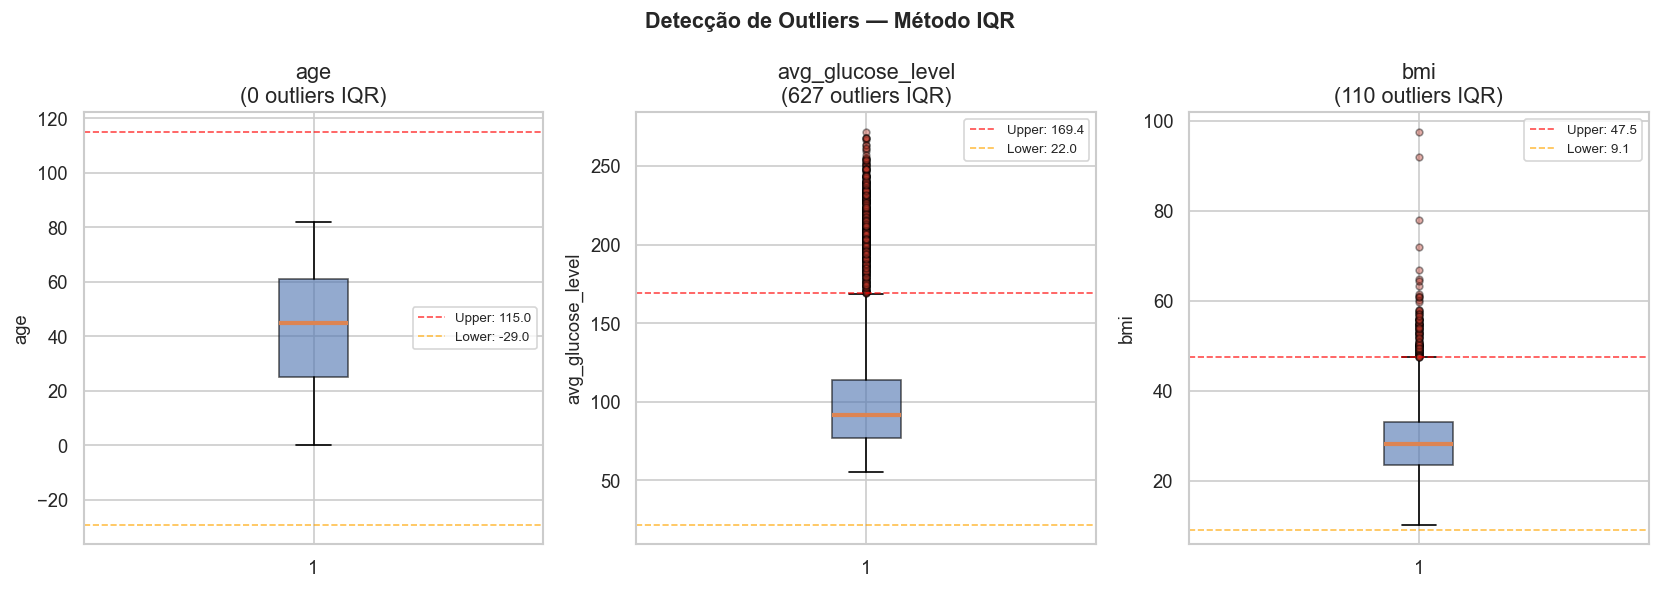

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()

    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='#DD8452', linewidth=2.5),
                    flierprops=dict(marker='o', markerfacecolor='#c0392b', alpha=0.4, markersize=4))
    axes[i].set_title(f'{col}\n({n_out} outliers IQR)')
    axes[i].set_ylabel(col)

    # Linhas de limite
    axes[i].axhline(upper, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Upper: {upper:.1f}')
    axes[i].axhline(lower, color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'Lower: {lower:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Detecção de Outliers — Método IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()


## 8. Pairplot — Variáveis Numéricas por Stroke

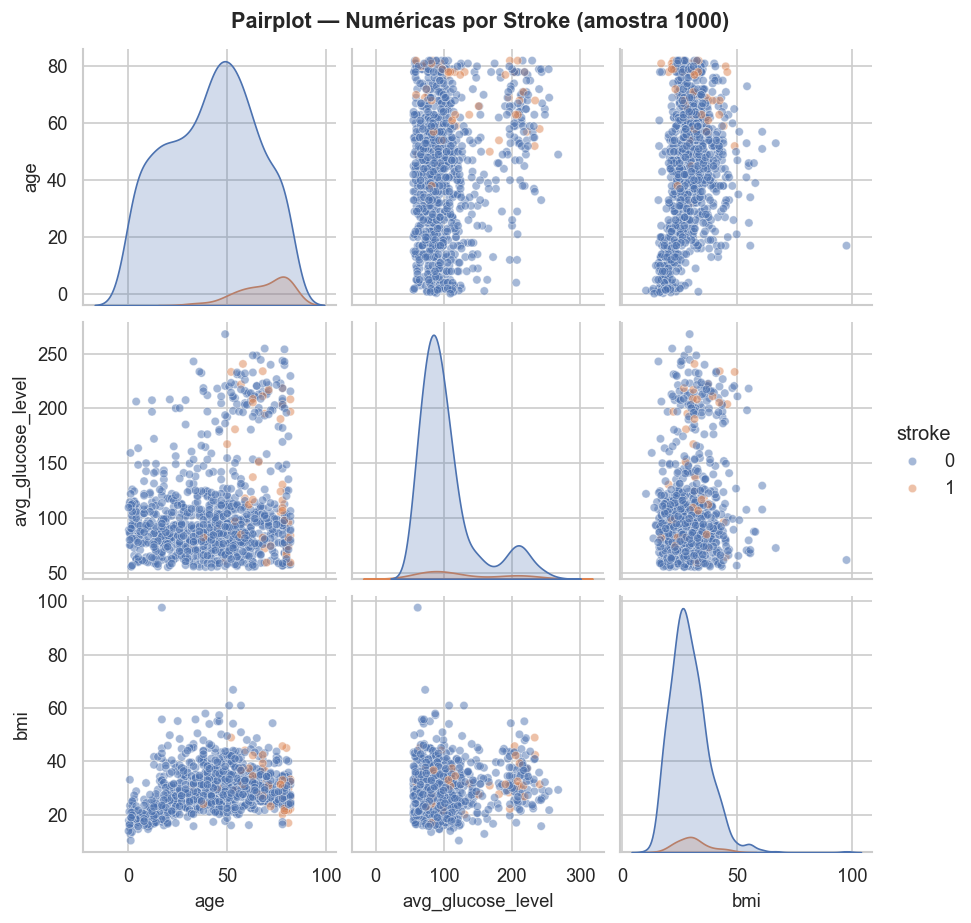

In [11]:
sample = df.dropna(subset=['bmi']).sample(min(1000, len(df)), random_state=42)
g = sns.pairplot(sample[['age', 'avg_glucose_level', 'bmi', 'stroke']],
                 hue='stroke', palette={0: '#4C72B0', 1: '#DD8452'},
                 plot_kws={'alpha': 0.5, 's': 25},
                 diag_kind='kde')
g.figure.suptitle('Pairplot — Numéricas por Stroke (amostra 1000)', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()


## 9. Análises de Cruzamento Relevantes

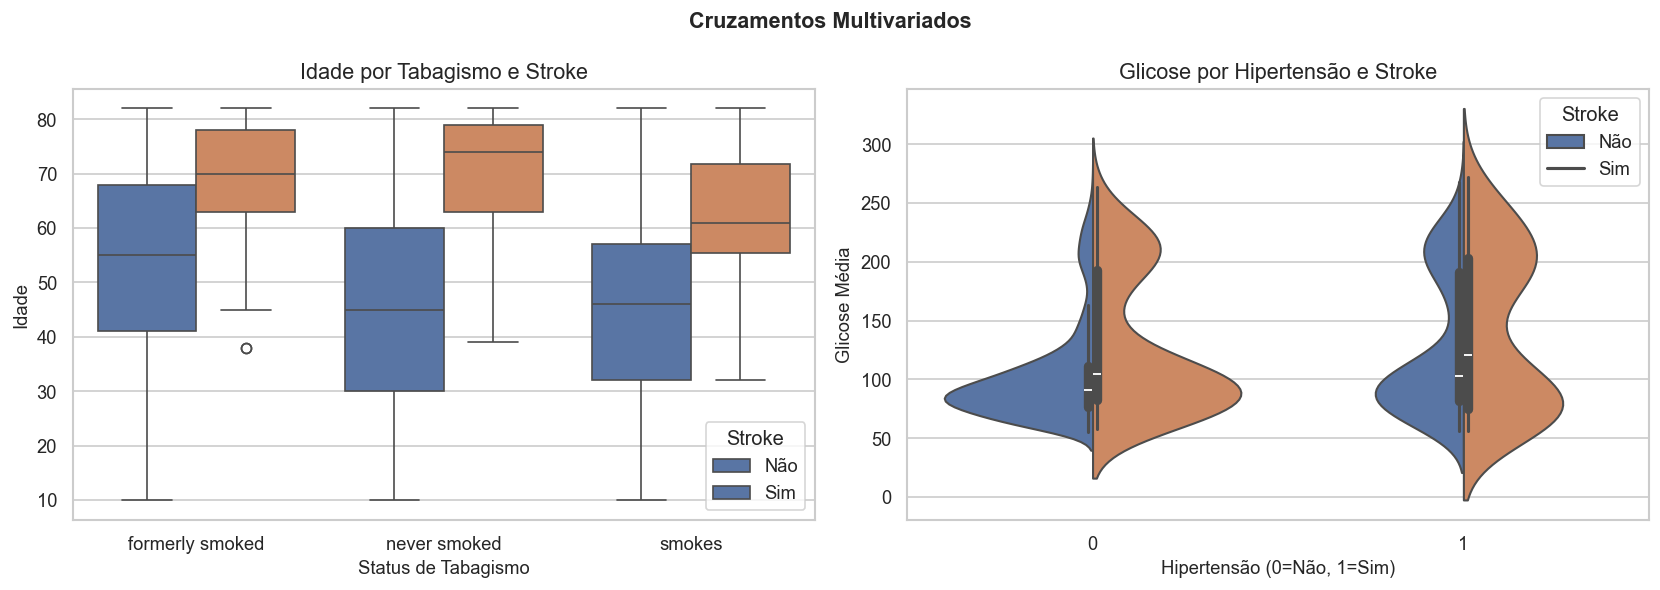

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Idade × Smoking status × Stroke
df_known_smoke = df[df['smoking_status'] != 'Unknown']
sns.boxplot(data=df_known_smoke, x='smoking_status', y='age', hue='stroke',
            palette={0: '#4C72B0', 1: '#DD8452'}, ax=axes[0])
axes[0].set_title('Idade por Tabagismo e Stroke')
axes[0].set_xlabel('Status de Tabagismo')
axes[0].set_ylabel('Idade')
axes[0].legend(title='Stroke', labels=['Não', 'Sim'])

# Glucose × Hypertension × Stroke
sns.violinplot(data=df, x='hypertension', y='avg_glucose_level', hue='stroke',
               palette={0: '#4C72B0', 1: '#DD8452'}, split=True, ax=axes[1])
axes[1].set_title('Glicose por Hipertensão e Stroke')
axes[1].set_xlabel('Hipertensão (0=Não, 1=Sim)')
axes[1].set_ylabel('Glicose Média')
axes[1].legend(title='Stroke', labels=['Não', 'Sim'])

plt.suptitle('Cruzamentos Multivariados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cruzamentos.png', bbox_inches='tight')
plt.show()


## 10. Resumo: Problemas Identificados e Tratamentos Necessários

### 🔴 Problemas Críticos
| # | Problema | Variável | Detalhe |
|---|----------|----------|---------|
| 1 | **Valores nulos** | `bmi` | 201 registros (~3.9%) com NaN |
| 2 | **Classe altamente desbalanceada** | `stroke` | 95.1% Não-AVC vs 4.9% AVC |
| 3 | **Categoria ambígua** | `smoking_status` | 1544 "Unknown" (30.2%) |
| 4 | **Outlier extremo em idade** | `age` | Mínimo = 0.08 anos (bebês) |
| 5 | **Categoria única** | `gender` | 1 registro "Other" — pode gerar problemas no encoding |

### 🟡 Tratamentos Recomendados
| Problema | Estratégia Recomendada |
|----------|----------------------|
| Nulos em `bmi` | Imputação pela **mediana** (distribuição assimétrica) ou KNN Imputer |
| Desbalanceamento | **SMOTE** / **class_weight='balanced'** / ajuste de threshold de decisão |
| "Unknown" em `smoking_status` | Tratar como categoria separada OU imputar via modelo |
| Outliers em `avg_glucose_level` / `bmi` | Winsorização (clip nos percentis 1-99) ou transformação log |
| Assimetria em `avg_glucose_level` | Transformação **log** ou Box-Cox |
| Encoding de categóricas | **One-Hot** para nominais (`gender`, `work_type`, etc.) |
| Coluna `id` | **Remover** — identificador sem valor preditivo |
| Escala | **StandardScaler** ou **MinMaxScaler** para modelos sensíveis a escala |

### 🟢 Pontos Positivos
- Sem duplicatas aparentes na maioria das variáveis
- Variáveis mais correlacionadas com stroke: **age**, **heart_disease**, **avg_glucose_level**, **hypertension**
- Dataset de tamanho razoável para um problema médico (5110 registros)


In [13]:
# Checklist final automatizado
print("=" * 55)
print("   CHECKLIST DE QUALIDADE DO DATASET")
print("=" * 55)

checks = {
    "Valores nulos (bmi)": df['bmi'].isnull().sum(),
    "Registros 'Other' em gender": (df['gender'] == 'Other').sum(),
    "Registros 'Unknown' em smoking_status": (df['smoking_status'] == 'Unknown').sum(),
    "Desbalanceamento target (% stroke=1)": f"{df['stroke'].mean()*100:.2f}%",
    "Outliers em bmi (IQR)": ((df['bmi'] > df['bmi'].quantile(0.75) + 1.5*(df['bmi'].quantile(0.75)-df['bmi'].quantile(0.25))) |
                               (df['bmi'] < df['bmi'].quantile(0.25) - 1.5*(df['bmi'].quantile(0.75)-df['bmi'].quantile(0.25)))).sum(),
    "Outliers em avg_glucose_level (IQR)": ((df['avg_glucose_level'] > df['avg_glucose_level'].quantile(0.75) + 1.5*(df['avg_glucose_level'].quantile(0.75)-df['avg_glucose_level'].quantile(0.25)))).sum(),
    "Total de registros": len(df),
    "Coluna id para remover": "✅ Sim",
}

for k, v in checks.items():
    print(f"  {'⚠️' if isinstance(v, (int, float)) and v > 0 else '✅'} {k}: {v}")


   CHECKLIST DE QUALIDADE DO DATASET
  ✅ Valores nulos (bmi): 201
  ✅ Registros 'Other' em gender: 1
  ✅ Registros 'Unknown' em smoking_status: 1544
  ✅ Desbalanceamento target (% stroke=1): 4.87%
  ✅ Outliers em bmi (IQR): 110
  ✅ Outliers em avg_glucose_level (IQR): 627
  ⚠️ Total de registros: 5110
  ✅ Coluna id para remover: ✅ Sim
